## A/B Testing — DerMind Capstone Project
**Mengimplementasikan A/B Testing menggunakan Python**

Notebook ini mengimplementasikan A/B Testing untuk menguji hipotesis bisnis
secara statistik menggunakan dataset DerMind.

---

## Apa itu A/B Testing?
A/B Testing adalah metode eksperimen statistik untuk membandingkan **dua kelompok (A dan B)**
dan menentukan apakah perbedaan yang diamati **signifikan secara statistik** atau hanya kebetulan.

**Komponen utama:**
- **H₀ (Hipotesis Null):** Tidak ada perbedaan antara grup A dan B
- **H₁ (Hipotesis Alternatif):** Ada perbedaan signifikan antara grup A dan B
- **α (Alpha):** Tingkat signifikansi = 0.05 (5%)
- **p-value:** Jika p-value < α → **tolak H₀** (perbedaan signifikan)

---

## 3 Eksperimen A/B Testing

| # | Eksperimen | Dataset | Uji Statistik |
|---|-----------|---------|---------------|
| 1 | Rating tinggi → lebih banyak direkomendasikan? | Sephora | Chi-Square Test |
| 2 | Teks kondisi klinis lebih panjang dari Normal? | Mental Health | Mann-Whitney U Test |
| 3 | Kota outdoor tinggi → happiness lebih tinggi? | Lifestyle | Independent T-Test |

## 1. Import Library & Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (
    chi2_contingency,   # Chi-Square Test
    mannwhitneyu,       # Mann-Whitney U Test
    ttest_ind,          # Independent T-Test
    shapiro,            # Shapiro-Wilk normality test
    levene              # Levene test for equal variance
)
import warnings
warnings.filterwarnings('ignore')

# ── DerMind color palette ──────────────────────────────────
G1 = '#059669'; G2 = '#10B981'; G3 = '#34D399'
BG = '#F8FAF9'; TX = '#1F2937'
R  = '#EF4444'; Y  = '#F59E0B'; BL = '#3B82F6'
PAL = [G1, R, '#94A3B8', BL, Y, '#8B5CF6']

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': '#F0FDF4',
    'axes.edgecolor': '#D1FAE5', 'axes.labelcolor': TX,
    'xtick.color': TX, 'ytick.color': TX,
    'text.color': TX, 'grid.color': '#D1FAE5',
    'figure.dpi': 120,
})

# Load dataset
df_sep  = pd.read_csv('master_sephora.csv', low_memory=False)
df_mh   = pd.read_csv('master_mental_health_clean.csv')
df_life = pd.read_csv('healthy_lifestyle_city_2021_cleaned.csv')
df_life.columns = ['city','rank','sunshine_hours','water_cost','obesity_levels',
                   'life_expectancy','pollution_index','hours_worked',
                   'happiness','outdoor_activities','takeout_places','gym_cost']
for col in ['sunshine_hours','pollution_index','hours_worked','outdoor_activities','happiness']:
    df_life[col] = pd.to_numeric(df_life[col], errors='coerce')

print('Dataset berhasil dimuat!')
print(f'   Sephora       : {len(df_sep):,} baris')
print(f'   Mental Health : {len(df_mh):,} baris')
print(f'   Lifestyle     : {len(df_life):,} baris')

# Konstanta level signifikansi
ALPHA = 0.05
print(f'\n   Tingkat signifikansi (α) = {ALPHA}')

Dataset berhasil dimuat!
   Sephora       : 49,394 baris
   Mental Health : 52,940 baris
   Lifestyle     : 44 baris

   Tingkat signifikansi (α) = 0.05


---
# EKSPERIMEN 1 — Chi-Square Test
## Apakah produk dengan rating tinggi lebih banyak direkomendasikan?
**Dataset:** `master_sephora.csv`

### 1.1 — Definisi Hipotesis & Grup

In [16]:
print('=' * 60)
print('EKSPERIMEN 1 — Chi-Square Test')
print('=' * 60)
print()
print('Pertanyaan Bisnis:')
print('   Apakah produk dengan rating tinggi secara signifikan')
print('   lebih banyak direkomendasikan oleh pengguna?')
print()
print('Definisi Grup:')
print('   Grup A (Kontrol)   : Rating rendah  (1, 2, 3)')
print('   Grup B (Treatment) : Rating tinggi  (4, 5)')
print()
print('Hipotesis:')
print('   H₀ : Tidak ada hubungan antara rating dan rekomendasi')
print('   H₁ : Ada hubungan signifikan antara rating dan rekomendasi')
print()
print('Uji Statistik: Chi-Square Test')
print('   Dipilih karena: kedua variabel bersifat kategorikal')
print('   (rating: rendah/tinggi) × (rekomendasi: ya/tidak)')
print(f'\n   α = {ALPHA}')

EKSPERIMEN 1 — Chi-Square Test

Pertanyaan Bisnis:
   Apakah produk dengan rating tinggi secara signifikan
   lebih banyak direkomendasikan oleh pengguna?

Definisi Grup:
   Grup A (Kontrol)   : Rating rendah  (1, 2, 3)
   Grup B (Treatment) : Rating tinggi  (4, 5)

Hipotesis:
   H₀ : Tidak ada hubungan antara rating dan rekomendasi
   H₁ : Ada hubungan signifikan antara rating dan rekomendasi

Uji Statistik: Chi-Square Test
   Dipilih karena: kedua variabel bersifat kategorikal
   (rating: rendah/tinggi) × (rekomendasi: ya/tidak)

   α = 0.05


### 1.2 — Persiapan Data & Contingency Table

In [17]:
# Buat kolom grup rating
df_exp1 = df_sep[['rating', 'is_recommended']].dropna().copy()
df_exp1['rating_group'] = df_exp1['rating'].apply(
    lambda x: 'Grup B (Rating Tinggi 4-5)' if x >= 4 else 'Grup A (Rating Rendah 1-3)'
)
df_exp1['recommended_label'] = df_exp1['is_recommended'].apply(
    lambda x: 'Direkomendasikan' if x == 1 else 'Tidak Direkomendasikan'
)

# Contingency table
contingency = pd.crosstab(
    df_exp1['rating_group'],
    df_exp1['recommended_label']
)

print('Contingency Table (jumlah):')
print(contingency)
print()

# Proporsi
contingency_pct = pd.crosstab(
    df_exp1['rating_group'],
    df_exp1['recommended_label'],
    normalize='index'
) * 100
print('Contingency Table (persentase %):')
print(contingency_pct.round(2))
print()
print(f'Total data: {len(df_exp1):,}')
print(f'Grup A (Rating 1-3): {(df_exp1.rating_group=="Grup A (Rating Rendah 1-3)").sum():,}')
print(f'Grup B (Rating 4-5): {(df_exp1.rating_group=="Grup B (Rating Tinggi 4-5)").sum():,}')

Contingency Table (jumlah):
recommended_label           Direkomendasikan  Tidak Direkomendasikan
rating_group                                                        
Grup A (Rating Rendah 1-3)              1285                    9050
Grup B (Rating Tinggi 4-5)             35802                    3257

Contingency Table (persentase %):
recommended_label           Direkomendasikan  Tidak Direkomendasikan
rating_group                                                        
Grup A (Rating Rendah 1-3)             12.43                   87.57
Grup B (Rating Tinggi 4-5)             91.66                    8.34

Total data: 49,394
Grup A (Rating 1-3): 10,335
Grup B (Rating 4-5): 39,059


### 1.3 — Jalankan Chi-Square Test

In [18]:
# Jalankan Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print('=' * 60)
print('HASIL CHI-SQUARE TEST')
print('=' * 60)
print(f'Chi-Square Statistic : {chi2:.4f}')
print(f'p-value              : {p_value:.6f}')
print(f'Degrees of Freedom   : {dof}')
print(f'Alpha (α)            : {ALPHA}')
print()

# Efek size — Cramér's V
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
effect_label = 'Kecil' if cramers_v < 0.1 else ('Sedang' if cramers_v < 0.3 else 'Besar')

print(f"Cramér's V (Effect Size) : {cramers_v:.4f} → {effect_label}")
print()

if p_value < ALPHA:
    print(f'KESIMPULAN: p-value ({p_value:.6f}) < α ({ALPHA})')
    print('   → TOLAK H₀')
    print('   → Ada hubungan SIGNIFIKAN antara rating dan rekomendasi')
    print('   → Produk rating tinggi (4-5) lebih banyak direkomendasikan')
else:
    print(f'KESIMPULAN: p-value ({p_value:.6f}) ≥ α ({ALPHA})')
    print('   → GAGAL TOLAK H₀')
    print('   → Tidak ada hubungan signifikan antara rating dan rekomendasi')

HASIL CHI-SQUARE TEST
Chi-Square Statistic : 27417.0426
p-value              : 0.000000
Degrees of Freedom   : 1
Alpha (α)            : 0.05

Cramér's V (Effect Size) : 0.7450 → Besar

KESIMPULAN: p-value (0.000000) < α (0.05)
   → TOLAK H₀
   → Ada hubungan SIGNIFIKAN antara rating dan rekomendasi
   → Produk rating tinggi (4-5) lebih banyak direkomendasikan


### 1.4 — Visualisasi Eksperimen 1

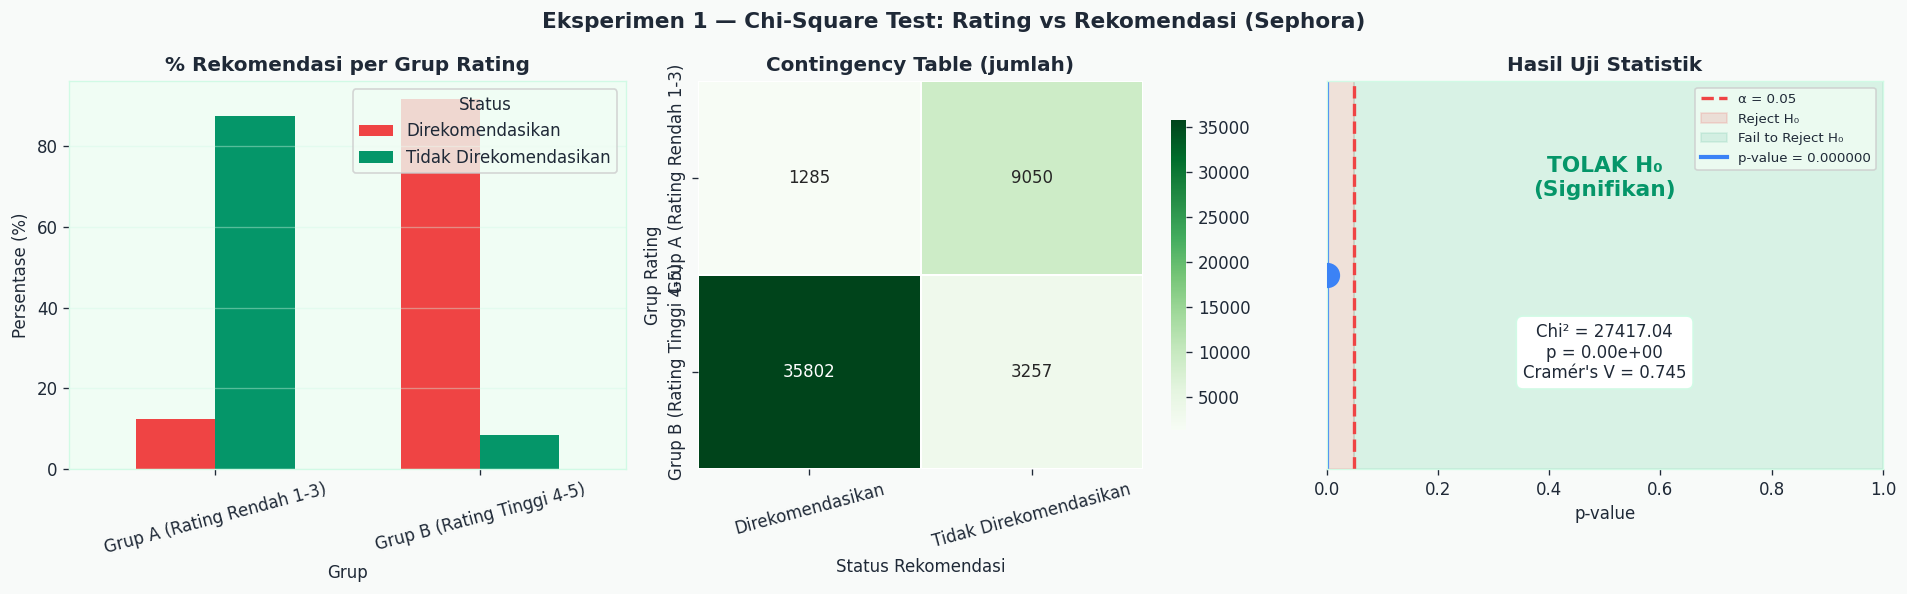

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Eksperimen 1 — Chi-Square Test: Rating vs Rekomendasi (Sephora)',
              fontsize=13, fontweight='bold')

# 1. Bar proporsi
contingency_pct.plot(kind='bar', ax=axes[0],
    color=[R, G1], edgecolor='none', width=0.6)
axes[0].set_title('% Rekomendasi per Grup Rating', fontweight='bold')
axes[0].set_ylabel('Persentase (%)')
axes[0].set_xlabel('Grup')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Status')
axes[0].grid(axis='y', alpha=0.4)

# 2. Heatmap contingency table
sns.heatmap(contingency, ax=axes[1], cmap='Greens', annot=True, fmt='d',
    linewidths=1, linecolor='white', cbar_kws={'shrink': 0.8})
axes[1].set_title('Contingency Table (jumlah)', fontweight='bold')
axes[1].set_xlabel('Status Rekomendasi')
axes[1].set_ylabel('Grup Rating')
axes[1].tick_params(axis='x', rotation=15)

# 3. p-value visualization
ax3 = axes[2]
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axvline(ALPHA, color=R, lw=2, ls='--', label=f'α = {ALPHA}')
ax3.axvspan(0, ALPHA, alpha=0.15, color=R, label='Reject H₀')
ax3.axvspan(ALPHA, 1, alpha=0.1, color=G1, label='Fail to Reject H₀')
p_plot = min(p_value, 0.99)
ax3.axvline(p_plot, color=BL, lw=2.5, label=f'p-value = {p_value:.6f}')
ax3.scatter([p_plot], [0.5], color=BL, s=200, zorder=5)
result_text = 'TOLAK H₀\n(Signifikan)' if p_value < ALPHA else 'GAGAL TOLAK H₀\n(Tidak Signifikan)'
result_color = G1 if p_value < ALPHA else R
ax3.text(0.5, 0.75, result_text, ha='center', va='center',
          fontsize=13, fontweight='bold', color=result_color,
          transform=ax3.transAxes)
ax3.text(0.5, 0.3, f"Chi² = {chi2:.2f}\np = {p_value:.2e}\nCramér's V = {cramers_v:.3f}",
          ha='center', va='center', fontsize=10, transform=ax3.transAxes,
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D1FAE5'))
ax3.set_title('Hasil Uji Statistik', fontweight='bold')
ax3.set_xlabel('p-value')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig('ab_test_exp1_sephora.png', bbox_inches='tight', facecolor=BG)
plt.show()

---
# EKSPERIMEN 2 — Mann-Whitney U Test
## Apakah teks kondisi klinis signifikan lebih panjang dari Normal?
**Dataset:** `master_mental_health_clean.csv`

### 2.1 — Definisi Hipotesis & Grup

In [20]:
print('=' * 60)
print('EKSPERIMEN 2 — Mann-Whitney U Test')
print('=' * 60)
print()
print('Pertanyaan Bisnis:')
print('   Apakah panjang teks (word_count) kondisi klinis')
print('   (Depression + Bipolar) secara signifikan lebih panjang')
print('   dibandingkan kondisi Normal?')
print()
print('Definisi Grup:')
print('   Grup A (Kontrol)   : Normal')
print('   Grup B (Treatment) : Kondisi Klinis (Depression + Bipolar)')
print()
print('Hipotesis:')
print('   H₀ : word_count Normal = word_count Kondisi Klinis')
print('   H₁ : word_count Kondisi Klinis > word_count Normal')
print()
print('Uji Statistik: Mann-Whitney U Test')
print('   Dipilih karena: data word_count tidak berdistribusi normal')
print('   (skewed) → uji non-parametrik lebih tepat dari T-Test')
print(f'\n   α = {ALPHA}')

EKSPERIMEN 2 — Mann-Whitney U Test

Pertanyaan Bisnis:
   Apakah panjang teks (word_count) kondisi klinis
   (Depression + Bipolar) secara signifikan lebih panjang
   dibandingkan kondisi Normal?

Definisi Grup:
   Grup A (Kontrol)   : Normal
   Grup B (Treatment) : Kondisi Klinis (Depression + Bipolar)

Hipotesis:
   H₀ : word_count Normal = word_count Kondisi Klinis
   H₁ : word_count Kondisi Klinis > word_count Normal

Uji Statistik: Mann-Whitney U Test
   Dipilih karena: data word_count tidak berdistribusi normal
   (skewed) → uji non-parametrik lebih tepat dari T-Test

   α = 0.05


### 2.2 — Cek Normalitas & Persiapan Data

In [21]:
# Ambil 2 grup
grup_a = df_mh[df_mh['label'] == 'Normal']['word_count'].dropna()
grup_b = df_mh[df_mh['label'].isin(['Depression', 'Bipolar'])]['word_count'].dropna()

print(f'Grup A (Normal)          : {len(grup_a):,} data')
print(f'  Mean   : {grup_a.mean():.2f} kata')
print(f'  Median : {grup_a.median():.2f} kata')
print(f'  Std    : {grup_a.std():.2f}')
print()
print(f'Grup B (Depression+Bipolar): {len(grup_b):,} data')
print(f'  Mean   : {grup_b.mean():.2f} kata')
print(f'  Median : {grup_b.median():.2f} kata')
print(f'  Std    : {grup_b.std():.2f}')
print()

# Cek normalitas (sampel kecil agar shapiro bisa jalan)
sample_a = grup_a.sample(min(500, len(grup_a)), random_state=42)
sample_b = grup_b.sample(min(500, len(grup_b)), random_state=42)
stat_a, p_norm_a = shapiro(sample_a)
stat_b, p_norm_b = shapiro(sample_b)
print('Uji Normalitas Shapiro-Wilk (sampel 500):')
print(f'   Grup A: W={stat_a:.4f}, p={p_norm_a:.6f}', '→ Tidak Normal' if p_norm_a < 0.05 else '→ Normal')
print(f'   Grup B: W={stat_b:.4f}, p={p_norm_b:.6f}', '→ Tidak Normal' if p_norm_b < 0.05 else '→ Normal')
print()
print('Karena data tidak normal → gunakan Mann-Whitney U Test (non-parametrik)')

Grup A (Normal)          : 16,127 data
  Mean   : 22.83 kata
  Median : 10.00 kata
  Std    : 48.28

Grup B (Depression+Bipolar): 18,461 data
  Mean   : 174.46 kata
  Median : 121.00 kata
  Std    : 192.77

Uji Normalitas Shapiro-Wilk (sampel 500):
   Grup A: W=0.4464, p=0.000000 → Tidak Normal
   Grup B: W=0.7088, p=0.000000 → Tidak Normal

Karena data tidak normal → gunakan Mann-Whitney U Test (non-parametrik)


### 2.3 — Jalankan Mann-Whitney U Test

In [22]:
# Mann-Whitney U Test (one-tailed: alternative='greater' → B > A)
u_stat, p_value_mw = mannwhitneyu(grup_b, grup_a, alternative='greater')

# Effect size — rank-biserial correlation
n1, n2 = len(grup_b), len(grup_a)
r_effect = 1 - (2 * u_stat) / (n1 * n2)
effect_label = 'Kecil' if abs(r_effect) < 0.1 else ('Sedang' if abs(r_effect) < 0.3 else 'Besar')

print('=' * 60)
print('HASIL MANN-WHITNEY U TEST')
print('=' * 60)
print(f'U Statistic              : {u_stat:.2f}')
print(f'p-value (one-tailed)     : {p_value_mw:.6f}')
print(f'Alpha (α)                : {ALPHA}')
print(f'Effect Size (r)          : {r_effect:.4f} → {effect_label}')
print()
print('Perbandingan Median:')
print(f'  Median Normal          : {grup_a.median():.0f} kata')
print(f'  Median Kondisi Klinis  : {grup_b.median():.0f} kata')
print(f'  Selisih Median         : {grup_b.median()-grup_a.median():.0f} kata')
print()

if p_value_mw < ALPHA:
    print(f'KESIMPULAN: p-value ({p_value_mw:.6f}) < α ({ALPHA})')
    print('   → TOLAK H₀')
    print('   → Teks kondisi klinis SIGNIFIKAN lebih panjang dari Normal')
    print('   → word_count adalah fitur PENTING untuk model klasifikasi')
else:
    print(f'KESIMPULAN: p-value ({p_value_mw:.6f}) ≥ α ({ALPHA})')
    print('   → GAGAL TOLAK H₀')
    print('   → Tidak ada perbedaan signifikan panjang teks antar kondisi')

HASIL MANN-WHITNEY U TEST
U Statistic              : 276797110.00
p-value (one-tailed)     : 0.000000
Alpha (α)                : 0.05
Effect Size (r)          : -0.8594 → Besar

Perbandingan Median:
  Median Normal          : 10 kata
  Median Kondisi Klinis  : 121 kata
  Selisih Median         : 111 kata

KESIMPULAN: p-value (0.000000) < α (0.05)
   → TOLAK H₀
   → Teks kondisi klinis SIGNIFIKAN lebih panjang dari Normal
   → word_count adalah fitur PENTING untuk model klasifikasi


### 2.4 — Visualisasi Eksperimen 2

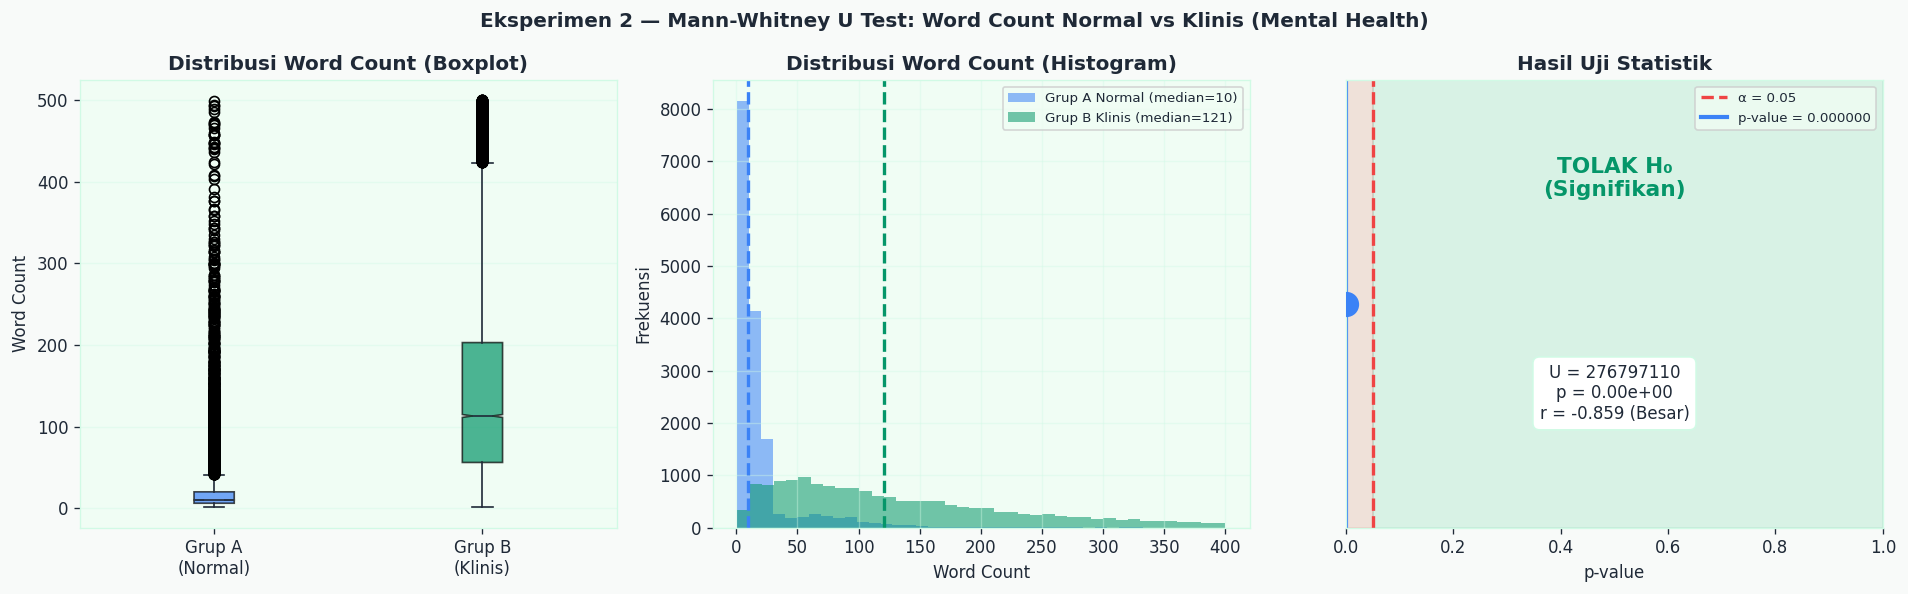

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Eksperimen 2 — Mann-Whitney U Test: Word Count Normal vs Klinis (Mental Health)',
              fontsize=12, fontweight='bold')

# 1. Boxplot perbandingan
data_box = [grup_a[grup_a <= 500].values, grup_b[grup_b <= 500].values]
bp = axes[0].boxplot(data_box, labels=['Grup A\n(Normal)', 'Grup B\n(Klinis)'],
                      patch_artist=True, notch=True)
colors_box = [BL, G1]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for el in ['whiskers','caps','medians']:
    for line in bp[el]: line.set_color(TX)
axes[0].set_title('Distribusi Word Count (Boxplot)', fontweight='bold')
axes[0].set_ylabel('Word Count')
axes[0].grid(axis='y', alpha=0.4)

# 2. Histogram overlay
axes[1].hist(grup_a[grup_a<=400], bins=40, alpha=0.55, color=BL,
              label=f'Grup A Normal (median={grup_a.median():.0f})', edgecolor='none')
axes[1].hist(grup_b[grup_b<=400], bins=40, alpha=0.55, color=G1,
              label=f'Grup B Klinis (median={grup_b.median():.0f})', edgecolor='none')
axes[1].axvline(grup_a.median(), color=BL, lw=2, ls='--')
axes[1].axvline(grup_b.median(), color=G1, lw=2, ls='--')
axes[1].set_title('Distribusi Word Count (Histogram)', fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frekuensi')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.4)

# 3. Hasil statistik
ax3 = axes[2]
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
ax3.axvline(ALPHA, color=R, lw=2, ls='--', label=f'α = {ALPHA}')
ax3.axvspan(0, ALPHA, alpha=0.15, color=R)
ax3.axvspan(ALPHA, 1, alpha=0.1, color=G1)
p_plot2 = min(p_value_mw, 0.99)
ax3.axvline(p_plot2, color=BL, lw=2.5, label=f'p-value = {p_value_mw:.6f}')
ax3.scatter([p_plot2], [0.5], color=BL, s=200, zorder=5)
result_text2 = 'TOLAK H₀\n(Signifikan)' if p_value_mw < ALPHA else 'GAGAL TOLAK H₀'
result_color2 = G1 if p_value_mw < ALPHA else R
ax3.text(0.5, 0.78, result_text2, ha='center', va='center',
          fontsize=13, fontweight='bold', color=result_color2,
          transform=ax3.transAxes)
ax3.text(0.5, 0.3,
          f"U = {u_stat:.0f}\np = {p_value_mw:.2e}\nr = {r_effect:.3f} ({effect_label})",
          ha='center', va='center', fontsize=10, transform=ax3.transAxes,
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D1FAE5'))
ax3.set_title('Hasil Uji Statistik', fontweight='bold')
ax3.set_xlabel('p-value')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig('ab_test_exp2_mental_health.png', bbox_inches='tight', facecolor=BG)
plt.show()

---
# EKSPERIMEN 3 — Independent T-Test
## Apakah kota dengan outdoor activities tinggi lebih bahagia?
**Dataset:** `healthy_lifestyle_city_2021_cleaned.csv`

### 3.1 — Definisi Hipotesis & Grup

In [24]:
print('=' * 60)
print('EKSPERIMEN 3 — Independent T-Test')
print('=' * 60)
print()
print('Pertanyaan Bisnis:')
print('   Apakah kota dengan outdoor activities tinggi memiliki')
print('   happiness score yang secara signifikan lebih tinggi?')
print()
print('Definisi Grup:')
print('   Grup A (Kontrol)   : Outdoor activities ≤ median (rendah)')
print('   Grup B (Treatment) : Outdoor activities > median (tinggi)')
print()
print('Hipotesis:')
print('   H₀ : Happiness Grup A = Happiness Grup B')
print('   H₁ : Happiness Grup B > Happiness Grup A')
print()
print('Uji Statistik: Independent T-Test (Welch\'s T-Test)')
print('   Dipilih karena: happiness score adalah variabel kontinu')
print('   dan kita membandingkan rata-rata 2 grup independen')
print(f'\n   α = {ALPHA}')

EKSPERIMEN 3 — Independent T-Test

Pertanyaan Bisnis:
   Apakah kota dengan outdoor activities tinggi memiliki
   happiness score yang secara signifikan lebih tinggi?

Definisi Grup:
   Grup A (Kontrol)   : Outdoor activities ≤ median (rendah)
   Grup B (Treatment) : Outdoor activities > median (tinggi)

Hipotesis:
   H₀ : Happiness Grup A = Happiness Grup B
   H₁ : Happiness Grup B > Happiness Grup A

Uji Statistik: Independent T-Test (Welch's T-Test)
   Dipilih karena: happiness score adalah variabel kontinu
   dan kita membandingkan rata-rata 2 grup independen

   α = 0.05


### 3.2 — Persiapan Data & Cek Asumsi

In [25]:
df_life_clean = df_life[['city','outdoor_activities','happiness']].dropna()

# Split berdasarkan median outdoor_activities
median_outdoor = df_life_clean['outdoor_activities'].median()
grup_a_life = df_life_clean[df_life_clean['outdoor_activities'] <= median_outdoor]['happiness']
grup_b_life = df_life_clean[df_life_clean['outdoor_activities'] > median_outdoor]['happiness']

print(f'Median outdoor_activities : {median_outdoor:.0f}')
print()
print(f'Grup A (Outdoor ≤ {median_outdoor:.0f}) : {len(grup_a_life)} kota')
print(f'  Mean happiness   : {grup_a_life.mean():.4f}')
print(f'  Median happiness : {grup_a_life.median():.4f}')
print(f'  Kota: {list(df_life_clean[df_life_clean["outdoor_activities"] <= median_outdoor]["city"])}')
print()
print(f'Grup B (Outdoor > {median_outdoor:.0f}) : {len(grup_b_life)} kota')
print(f'  Mean happiness   : {grup_b_life.mean():.4f}')
print(f'  Median happiness : {grup_b_life.median():.4f}')
print(f'  Kota: {list(df_life_clean[df_life_clean["outdoor_activities"] > median_outdoor]["city"])}')
print()

# Cek normalitas
stat_la, p_norm_la = shapiro(grup_a_life)
stat_lb, p_norm_lb = shapiro(grup_b_life)
print('Uji Normalitas Shapiro-Wilk:')
print(f'   Grup A: W={stat_la:.4f}, p={p_norm_la:.4f}', '→ Normal' if p_norm_la >= 0.05 else '→ Tidak Normal')
print(f'   Grup B: W={stat_lb:.4f}, p={p_norm_lb:.4f}', '→ Normal' if p_norm_lb >= 0.05 else '→ Tidak Normal')

# Cek equal variance (Levene)
lev_stat, lev_p = levene(grup_a_life, grup_b_life)
print(f'\n Levene Test (Equal Variance):')
print(f'   p={lev_p:.4f}', '→ Variance equal' if lev_p >= 0.05 else '→ Variance tidak equal → pakai Welch T-Test')

Median outdoor_activities : 190

Grup A (Outdoor ≤ 190) : 22 kota
  Mean happiness   : 6.5895
  Median happiness : 6.9400
  Kota: ['Vienna', 'Stockholm', 'Copenhagen', 'Helsinki', 'Fukuoka', 'Toronto', 'Jakarta', 'Seoul', 'Frankfurt', 'Geneva', 'Tel Aviv', 'Taipei', 'Mumbai', 'Boston', 'Dublin', 'Chicago', 'Shanghai', 'Brussels', 'Sao Paulo', 'Zurich', 'Milan', 'Washington, D.C.']

Grup B (Outdoor > 190) : 22 kota
  Mean happiness   : 6.2805
  Median happiness : 6.4300
  Kota: ['Amsterdam', 'Sydney', 'Berlin', 'Barcelona', 'Vancouver', 'Melbourne', 'Beijing', 'Bangkok', 'Buenos Aires', 'Madrid', 'Istanbul', 'Cairo', 'Los Angeles', 'Tokyo', 'Hong Kong', 'San Francisco', 'Paris', 'London', 'Johannesburg', 'New York', 'Moscow', 'Mexico City']

Uji Normalitas Shapiro-Wilk:
   Grup A: W=0.8641, p=0.0061 → Tidak Normal
   Grup B: W=0.9209, p=0.0794 → Normal

 Levene Test (Equal Variance):
   p=0.9896 → Variance equal


### 3.3 — Jalankan Independent T-Test

In [26]:
# Welch's T-Test (equal_var=False) — lebih robust
t_stat, p_value_t = ttest_ind(grup_b_life, grup_a_life,
                               equal_var=False, alternative='greater')

# Effect size — Cohen's d
pooled_std = np.sqrt((grup_a_life.std()**2 + grup_b_life.std()**2) / 2)
cohens_d = (grup_b_life.mean() - grup_a_life.mean()) / pooled_std
effect_label_t = 'Kecil' if abs(cohens_d) < 0.2 else ('Sedang' if abs(cohens_d) < 0.8 else 'Besar')

# 95% Confidence Interval
diff_mean = grup_b_life.mean() - grup_a_life.mean()
se_diff = np.sqrt(grup_a_life.std()**2/len(grup_a_life) + grup_b_life.std()**2/len(grup_b_life))
ci_low  = diff_mean - 1.96 * se_diff
ci_high = diff_mean + 1.96 * se_diff

print('=' * 60)
print('HASIL INDEPENDENT T-TEST (WELCH\'S)')
print('=' * 60)
print(f'T Statistic              : {t_stat:.4f}')
print(f'p-value (one-tailed)     : {p_value_t:.6f}')
print(f'Alpha (α)                : {ALPHA}')
print(f"Cohen's d (Effect Size)  : {cohens_d:.4f} → {effect_label_t}")
print(f'95% CI selisih mean      : [{ci_low:.4f}, {ci_high:.4f}]')
print()
print('Perbandingan Mean Happiness:')
print(f'  Grup A (Outdoor Rendah): {grup_a_life.mean():.4f}')
print(f'  Grup B (Outdoor Tinggi): {grup_b_life.mean():.4f}')
print(f'  Selisih Mean           : {diff_mean:.4f}')
print()

if p_value_t < ALPHA:
    print(f'KESIMPULAN: p-value ({p_value_t:.6f}) < α ({ALPHA})')
    print('   → TOLAK H₀')
    print('   → Kota outdoor activities tinggi SIGNIFIKAN lebih bahagia')
    print('   → Konten artikel wellness DerMind terbukti relevan secara statistik')
else:
    print(f'KESIMPULAN: p-value ({p_value_t:.6f}) ≥ α ({ALPHA})')
    print('   → GAGAL TOLAK H₀')
    print('   → Tidak ada perbedaan signifikan happiness antar grup outdoor')

HASIL INDEPENDENT T-TEST (WELCH'S)
T Statistic              : -1.0351
p-value (one-tailed)     : 0.846671
Alpha (α)                : 0.05
Cohen's d (Effect Size)  : -0.3121 → Sedang
95% CI selisih mean      : [-0.8944, 0.2762]

Perbandingan Mean Happiness:
  Grup A (Outdoor Rendah): 6.5895
  Grup B (Outdoor Tinggi): 6.2805
  Selisih Mean           : -0.3091

KESIMPULAN: p-value (0.846671) ≥ α (0.05)
   → GAGAL TOLAK H₀
   → Tidak ada perbedaan signifikan happiness antar grup outdoor


### 3.4 — Visualisasi Eksperimen 3

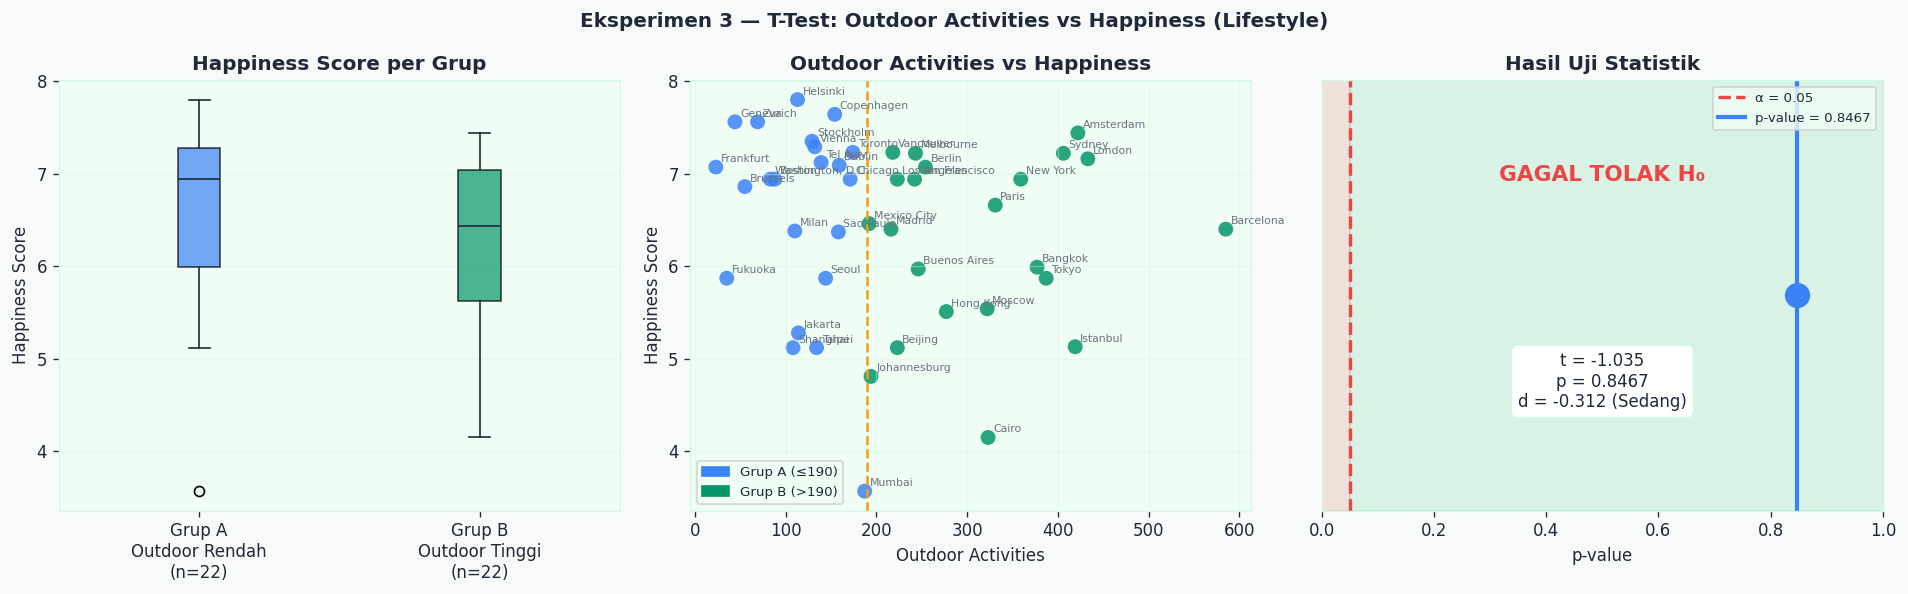

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Eksperimen 3 — T-Test: Outdoor Activities vs Happiness (Lifestyle)',
              fontsize=12, fontweight='bold')

# 1. Boxplot
bp = axes[0].boxplot(
    [grup_a_life.values, grup_b_life.values],
    labels=[f'Grup A\nOutdoor Rendah\n(n={len(grup_a_life)})',
            f'Grup B\nOutdoor Tinggi\n(n={len(grup_b_life)})'],
    patch_artist=True, notch=False
)
for patch, color in zip(bp['boxes'], [BL, G1]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for el in ['whiskers','caps','medians']:
    for line in bp[el]: line.set_color(TX)
axes[0].set_title('Happiness Score per Grup', fontweight='bold')
axes[0].set_ylabel('Happiness Score')
axes[0].grid(axis='y', alpha=0.4)

# 2. Scatter dengan warna grup
for _, row in df_life_clean.iterrows():
    color = G1 if row['outdoor_activities'] > median_outdoor else BL
    axes[1].scatter(row['outdoor_activities'], row['happiness'],
                     color=color, s=80, alpha=0.85, edgecolors='none')
    axes[1].annotate(row['city'], (row['outdoor_activities'], row['happiness']),
                      xytext=(3,3), textcoords='offset points', fontsize=6.5, color='#6B7280')
axes[1].axvline(median_outdoor, color=Y, ls='--', lw=1.5, label=f'Median ({median_outdoor:.0f})')
patch_a = mpatches.Patch(color=BL, label=f'Grup A (≤{median_outdoor:.0f})')
patch_b = mpatches.Patch(color=G1, label=f'Grup B (>{median_outdoor:.0f})')
axes[1].legend(handles=[patch_a, patch_b], fontsize=8)
axes[1].set_title('Outdoor Activities vs Happiness', fontweight='bold')
axes[1].set_xlabel('Outdoor Activities')
axes[1].set_ylabel('Happiness Score')
axes[1].grid(alpha=0.4)

# 3. Hasil statistik
ax3 = axes[2]
ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
ax3.axvline(ALPHA, color=R, lw=2, ls='--', label=f'α = {ALPHA}')
ax3.axvspan(0, ALPHA, alpha=0.15, color=R)
ax3.axvspan(ALPHA, 1, alpha=0.1, color=G1)
p_plot3 = min(p_value_t, 0.99)
ax3.axvline(p_plot3, color=BL, lw=2.5, label=f'p-value = {p_value_t:.4f}')
ax3.scatter([p_plot3], [0.5], color=BL, s=200, zorder=5)
result_text3 = 'TOLAK H₀\n(Signifikan)' if p_value_t < ALPHA else 'GAGAL TOLAK H₀'
result_color3 = G1 if p_value_t < ALPHA else R
ax3.text(0.5, 0.78, result_text3, ha='center', va='center',
          fontsize=13, fontweight='bold', color=result_color3,
          transform=ax3.transAxes)
ax3.text(0.5, 0.3,
          f"t = {t_stat:.3f}\np = {p_value_t:.4f}\nd = {cohens_d:.3f} ({effect_label_t})",
          ha='center', va='center', fontsize=10, transform=ax3.transAxes,
          bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#D1FAE5'))
ax3.set_title('Hasil Uji Statistik', fontweight='bold')
ax3.set_xlabel('p-value')
ax3.legend(fontsize=8, loc='upper right')
ax3.set_yticks([])

plt.tight_layout()
plt.savefig('ab_test_exp3_lifestyle.png', bbox_inches='tight', facecolor=BG)
plt.show()

---
# RINGKASAN HASIL A/B TESTING

In [28]:
print('=' * 70)
print('  RINGKASAN HASIL A/B TESTING — DerMind Capstone Project')
print('=' * 70)
print(f'  Tingkat Signifikansi (α) = {ALPHA}')
print()

results = [
    {
        'exp'    : 'Exp 1 — Chi-Square',
        'dataset': 'Sephora',
        'hipotesis': 'Rating tinggi → lebih direkomendasikan?',
        'uji'    : 'Chi-Square Test',
        'stat'   : f'χ²={chi2:.2f}',
        'pval'   : p_value,
        'effect' : f"Cramér's V={cramers_v:.3f} ({('Kecil' if cramers_v<0.1 else 'Sedang' if cramers_v<0.3 else 'Besar')})",
        'result' : 'TOLAK H₀' if p_value < ALPHA else 'GAGAL TOLAK H₀',
    },
    {
        'exp'    : 'Exp 2 — Mann-Whitney',
        'dataset': 'Mental Health',
        'hipotesis': 'Teks klinis lebih panjang dari Normal?',
        'uji'    : 'Mann-Whitney U Test',
        'stat'   : f'U={u_stat:.0f}',
        'pval'   : p_value_mw,
        'effect' : f'r={r_effect:.3f} ({effect_label})',
        'result' : 'TOLAK H₀' if p_value_mw < ALPHA else 'GAGAL TOLAK H₀',
    },
    {
        'exp'    : 'Exp 3 — T-Test',
        'dataset': 'Lifestyle',
        'hipotesis': 'Outdoor tinggi → lebih bahagia?',
        'uji'    : 'Independent T-Test',
        'stat'   : f't={t_stat:.3f}',
        'pval'   : p_value_t,
        'effect' : f"Cohen's d={cohens_d:.3f} ({effect_label_t})",
        'result' : 'TOLAK H₀' if p_value_t < ALPHA else 'GAGAL TOLAK H₀',
    },
]

for r in results:
    status = '✅' if 'TOLAK' in r['result'] and 'GAGAL' not in r['result'] else '❌'
    print(f"{status} {r['exp']} ({r['dataset']})")
    print(f"   Hipotesis : {r['hipotesis']}")
    print(f"   Uji       : {r['uji']}")
    print(f"   Statistik : {r['stat']} | p-value = {r['pval']:.6f}")
    print(f"   Effect    : {r['effect']}")
    print(f"   Keputusan : {r['result']}")
    print()

print('=' * 70)
print('IMPLIKASI BISNIS:')
print('  Exp 1 → Sistem rating Sephora valid → basis rekomendasi produk di artikel DerMind')
print('  Exp 2 → word_count adalah fitur penting → wajib masuk training model AI Chatbot')
print('  Exp 3 → Outdoor activity terbukti meningkatkan kebahagiaan → konten wellness valid')
print('=' * 70)

  RINGKASAN HASIL A/B TESTING — DerMind Capstone Project
  Tingkat Signifikansi (α) = 0.05

✅ Exp 1 — Chi-Square (Sephora)
   Hipotesis : Rating tinggi → lebih direkomendasikan?
   Uji       : Chi-Square Test
   Statistik : χ²=27417.04 | p-value = 0.000000
   Effect    : Cramér's V=0.745 (Besar)
   Keputusan : TOLAK H₀

✅ Exp 2 — Mann-Whitney (Mental Health)
   Hipotesis : Teks klinis lebih panjang dari Normal?
   Uji       : Mann-Whitney U Test
   Statistik : U=276797110 | p-value = 0.000000
   Effect    : r=-0.859 (Besar)
   Keputusan : TOLAK H₀

❌ Exp 3 — T-Test (Lifestyle)
   Hipotesis : Outdoor tinggi → lebih bahagia?
   Uji       : Independent T-Test
   Statistik : t=-1.035 | p-value = 0.846671
   Effect    : Cohen's d=-0.312 (Sedang)
   Keputusan : GAGAL TOLAK H₀

IMPLIKASI BISNIS:
  Exp 1 → Sistem rating Sephora valid → basis rekomendasi produk di artikel DerMind
  Exp 2 → word_count adalah fitur penting → wajib masuk training model AI Chatbot
  Exp 3 → Outdoor activity terbukt